# step to customer segment
* 1- scaling (bacuse it is important before cluster)
* 2- select No. K by Elpow method
* 3- apply K-means Cluster
* 4- Cluster Analysis
* 5- Visualization
* 6- Customer Labeling (Business Naming)
* 7- EDA

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import warnings
from sklearn.decomposition import PCA
import seaborn as sns
warnings.filterwarnings('ignore')
from sklearn.metrics import silhouette_score
import joblib


In [2]:
rfm_tb = pd.read_csv('rfm_table.csv')
rfm_tb.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1797.24
3,12349,18,1,1757.55
4,12350,309,1,334.40


In [3]:
rfm_tb = rfm_tb.drop('CustomerID', axis=1)
rfm_tb.head()

,Recency,Frequency,Monetary
0,325,1,77183.60
1,1,7,4310.00
2,74,4,1797.24
3,18,1,1757.55
4,309,1,334.40


* 1- scaling (bacuse it is important before cluster)

In [4]:
scaler = StandardScaler()
rfm_tb_scaled = scaler.fit_transform(rfm_tb)
rfm_tb_scaled = pd.DataFrame(rfm_tb_scaled, columns=rfm_tb.columns)
rfm_tb_scaled.head()

,Recency,Frequency,Monetary
0,2.334574,-0.425097,8.363010
1,-0.905340,0.354417,0.251699
2,-0.175360,-0.035340,-0.027988
3,-0.735345,-0.425097,-0.032406
4,2.174578,-0.425097,-0.190812


* 2- select No. K by Elpow method

  File "c:\Users\lenovo\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\lenovo\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenovo\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\lenovo\anaconda3\Lib\subproc

k=2, Silhouette=0.560
k=3, Silhouette=0.585
k=4, Silhouette=0.616
k=5, Silhouette=0.617
k=6, Silhouette=0.598
k=7, Silhouette=0.517
k=8, Silhouette=0.491
k=9, Silhouette=0.478


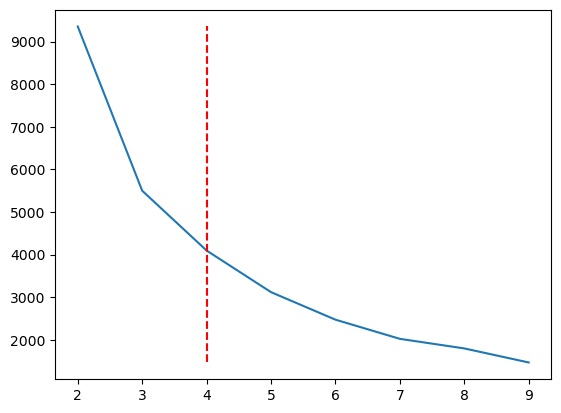

In [5]:
sse = []
sil_scores = []

for k in range(2, 10):   # 👈 يبدأ من 2
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_tb_scaled)

    sse.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(rfm_tb_scaled, labels))

    print(f'k={k}, Silhouette={sil_scores[-1]:.3f}')

plt.plot(range(2,10), sse)
plt.vlines(x=4, ymin=min(sse), ymax=max(sse), colors='r', linestyles='--')
plt.show()
# select done k = 4
# silhouette_score if from (0.5-0.8) is good score for clustering
# silhouette_score if drom (0.2-0.5) is average score for clustering --- need improve(feature or ...)
# silhouette_score if from (0-0.2) is bad score for clustering

* 3- apply K-means Cluster

In [6]:
kmeans = KMeans(n_clusters=4 , random_state=42)
rfm_tb['cluster'] = kmeans.fit_predict(rfm_tb_scaled)
rfm_tb

,Recency,Frequency,Monetary,cluster
0,325,1,77183.60,3
1,1,7,4310.00,0
2,74,4,1797.24,0
3,18,1,1757.55,0
4,309,1,334.40,1
...,...,...,...,...
4333,277,1,180.60,1
4334,180,1,80.82,1
4335,7,2,178.05,0
4336,3,16,2045.53,3


In [7]:
rfm_tb['cluster'].unique()

array([3, 0, 1, 2], dtype=int32)

<img src='images\segment customer.png' width=500>

* 4- Cluster Analysis

* Cluster 0
Monetary: Moderate (1,353)
Frequency: Low (3.68)
Recency: Moderate (approx. 42 days)

👉 Profile:
Customers with low engagement but moderate spending

🎯 Business Insight:
Customers who make occasional purchases but do not buy frequently; they can be re-engaged through offers.

---

* Cluster 1
Monetary: Low (478)
Frequency: Very low (1.55)
Recency: Very high (247 days)

👉 Description:
Churned / Inactive customers

🎯 Business Insight:
Customers we have effectively lost; they require strong reactivation campaigns or should be temporarily ignored.

---

* Cluster 2
Monetary: Very High (127,187)
Frequency: Very High (82.5)
Recency: Very Low (6 days)

👉 Profile:
VIP / Loyal customers

🎯 Business Insight:
My best customers; they make frequent, high-value purchases and are very recent → They require a dedicated loyalty program.
---
* Cluster 3
Monetary: High (12,690)
Frequency: Medium (22)
Recency: Low (14.5)

👉 Profile:
Active high-value customers

🎯 Business Insight:
Active, high-value customers—though not quite VIPs—presenting an opportunity to upgrade them to VIP status.

In [8]:
rfm_tb.groupby('cluster')[['Monetary' , 'Frequency' , 'Recency']].mean()

,Monetary,Frequency,Recency
cluster,,,
0,1353.625312,3.682711,42.702685
1,478.848773,1.552015,247.075914
2,127187.959231,82.538462,6.384615
3,12690.500392,22.333333,14.500000


* 5- Visualization

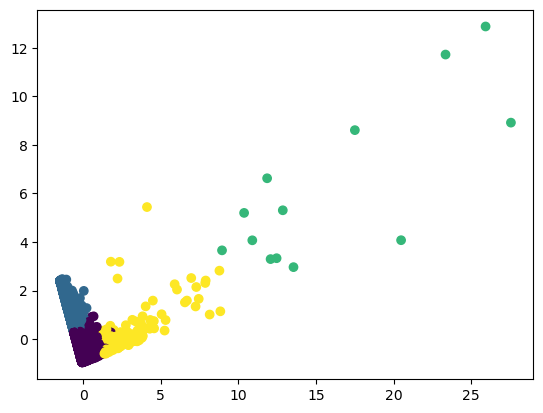

In [9]:
pca = PCA(n_components=2)
components = pca.fit_transform(rfm_tb_scaled)

plt.scatter(components[:,0], components[:,1], c=rfm_tb['cluster'])
plt.show()

* 6- Customer Labeling (Business Naming)

In [10]:
cluster_map = {
    0: 'Occasional',
    1: 'Churned',
    2: 'VIP',
    3: 'Active valuable'
}

rfm_tb['Segment'] = rfm_tb['cluster'].map(cluster_map)

rfm_tb.head()

,Recency,Frequency,Monetary,cluster,Segment
0,325,1,77183.60,3,Active valuable
1,1,7,4310.00,0,Occasional
2,74,4,1797.24,0,Occasional
3,18,1,1757.55,0,Occasional
4,309,1,334.40,1,Churned


In [11]:
rfm_tb = rfm_tb.drop('cluster', axis=1)
rfm_tb.to_csv('rfm_table_with_segments.csv', index=False)

* 7- EDA

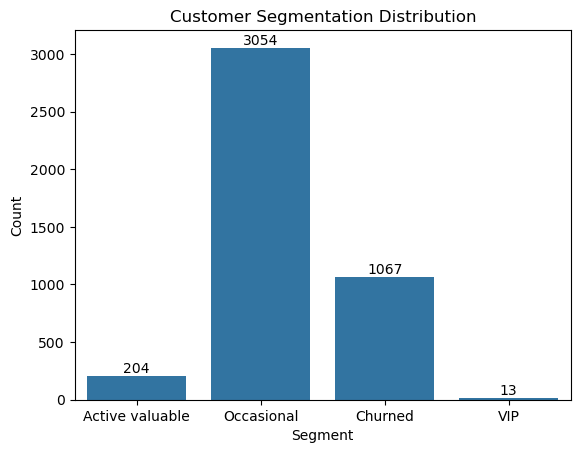

In [12]:
ax = sns.countplot(x='Segment', data=rfm_tb)

plt.title('Customer Segmentation Distribution')
plt.xlabel('Segment')
plt.ylabel('Count')

# إضافة labels
ax.bar_label(ax.containers[0])

plt.show()

In [13]:
joblib.dump(kmeans, "kmeans.pkl")

['kmeans.pkl']